# Lung Cancer Survival Prediction: Gradient Boosting
Target: **`survived`** (1 = survived, 0 = did not survive). This is a binary classification task.

Steps: 1) Load data, 2) Inspect and preprocess, 3) Train/test split, 4) Baseline, 5) Gradient Boosting, 6) Evaluation, 7) Feature importance, 8) Hyperparameter tuning.

## 1. Load the data
Run this cell and choose `lung_cancer_processed.csv` when the upload box appears. If you only have the zip, upload that instead and the cell will unzip it.

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, zipfile, os, time
try:
    from google.colab import files
    up = files.upload()
    name = list(up.keys())[0]
    if name.endswith(".zip"):
        zipfile.ZipFile(name).extractall(".")
        name = "lung_cancer_processed.csv"
except ImportError:
    name = "lung_cancer_processed.csv"   # running outside Colab

df = pd.read_csv(name)
print(df.shape)
df.head()

Saving lung_cancer_processed.zip to lung_cancer_processed.zip
(886105, 22)


,age,gender,country,cancer_stage,family_history,bmi,cholesterol_level,hypertension,asthma,cirrhosis,...,treatment_duration_days,diagnosis_year,smoking_Current Smoker,smoking_Former Smoker,smoking_Never Smoked,smoking_Passive Smoker,treatment_Chemotherapy,treatment_Combined,treatment_Radiation,treatment_Surgery
0,0.918122,0,26,1,1,-0.130726,-0.797375,0,0,1,...,0.466017,2016,0,0,0,1,1,0,0,0
1,-0.511199,1,19,3,1,1.279336,1.067513,1,1,0,...,-0.244589,2023,0,0,0,1,0,0,0,1
2,1.020216,1,12,3,1,1.613927,0.791233,1,1,0,...,-0.632192,2023,0,1,0,0,0,1,0,0
3,-0.409104,1,1,1,0,1.494430,0.169604,1,1,0,...,-0.108210,2016,0,0,0,1,1,0,0,0
4,-1.838425,0,17,1,0,-1.289845,-1.280865,0,0,0,...,-0.373790,2023,0,0,0,1,0,1,0,0


## 2. Inspect and preprocess
This file is already *processed*: categorical columns are one-hot or label encoded, and `age`, `bmi`, `cholesterol_level` and `treatment_duration_days` are standardised. The checks below confirm nothing else needs fixing.

Missing values: 0
Duplicate rows: 0
int64      18
float64     4
Name: count, dtype: int64

Class balance (survived):
survived
0    0.78
1    0.22
Name: proportion, dtype: float64


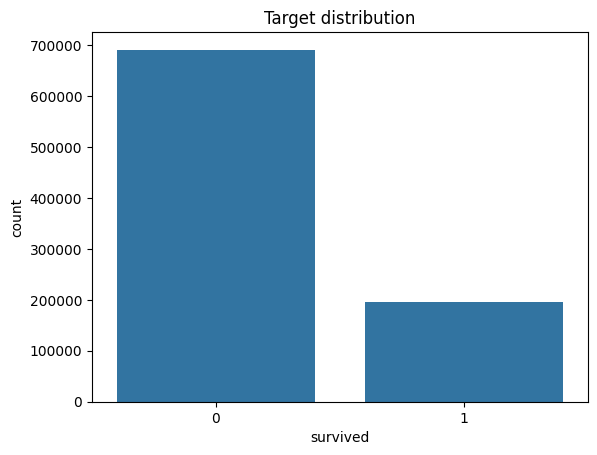

In [ ]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df.dtypes.value_counts())
print("\nClass balance (survived):")
print(df["survived"].value_counts(normalize=True).round(3))
sns.countplot(x="survived", data=df); plt.title("Target distribution"); plt.show()

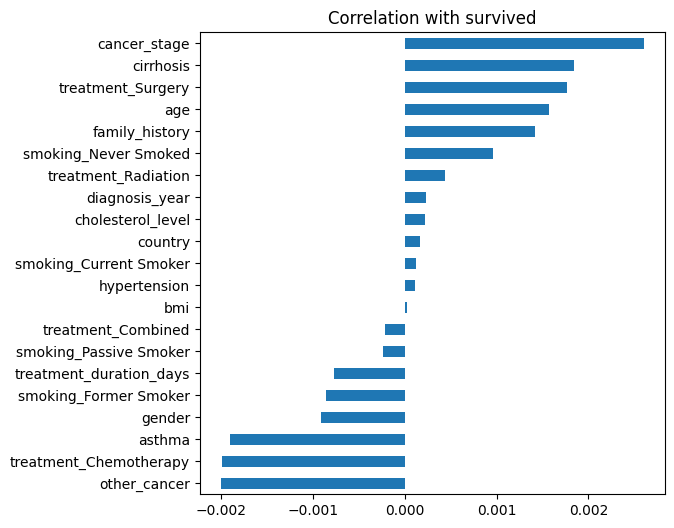

In [ ]:
# Remove duplicates / missing rows if any (none expected here)
df = df.drop_duplicates().dropna().reset_index(drop=True)

# Correlation of each feature with the target
corr = df.corr()["survived"].drop("survived").sort_values()
corr.plot(kind="barh", figsize=(6,6), title="Correlation with survived"); plt.show()

## 3. Train / test split
A stratified split keeps the same survived/not-survived ratio in both sets.

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns="survived")
y = df["survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(708884, 21) (177221, 21)


## 4. Baseline
A model that always predicts the majority class. Any real model must beat this.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Baseline accuracy:", round(accuracy_score(y_test, dummy.predict(X_test)), 4))

Baseline accuracy: 0.7798


## 5. Gradient Boosting
The full dataset has ~886,000 rows. scikit-learn's classic `GradientBoostingClassifier` is slow at that size, so we train it on a stratified 100,000-row sample. We also train `HistGradientBoostingClassifier` (the same algorithm, histogram-based) on **all** rows.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

# Classic Gradient Boosting on a 100k stratified sample
X_s, _, y_s, _ = train_test_split(X_train, y_train, train_size=100_000,
                                  random_state=42, stratify=y_train)
t = time.time()
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                max_depth=3, subsample=0.8, random_state=42)
gb.fit(X_s, y_s)
print(f"GradientBoostingClassifier trained in {time.time()-t:.0f}s")

# Histogram Gradient Boosting on ALL training rows
t = time.time()
hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                     early_stopping=True, random_state=42)
hgb.fit(X_train, y_train)
print(f"HistGradientBoostingClassifier trained in {time.time()-t:.0f}s")

GradientBoostingClassifier trained in 25s
HistGradientBoostingClassifier trained in 2s


## 6. Evaluation

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             precision_score, recall_score, f1_score)

models = {"Baseline": dummy, "GradientBoosting": gb, "HistGradientBoosting": hgb}
rows = []
for n, m in models.items():
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    rows.append({"model": n,
                 "accuracy": accuracy_score(y_test, pred),
                 "precision": precision_score(y_test, pred, zero_division=0),
                 "recall": recall_score(y_test, pred),
                 "f1": f1_score(y_test, pred),
                 "roc_auc": roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).round(4)
results

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline,0.7798,0.0000,0.0000,0.0000,0.5000
1,GradientBoosting,0.7797,0.2143,0.0001,0.0002,0.4989
2,HistGradientBoosting,0.7798,0.0000,0.0000,0.0000,0.4997


              precision    recall  f1-score   support

           0       0.78      1.00      0.88    138196
           1       0.21      0.00      0.00     39025

    accuracy                           0.78    177221
   macro avg       0.50      0.50      0.44    177221
weighted avg       0.66      0.78      0.68    177221



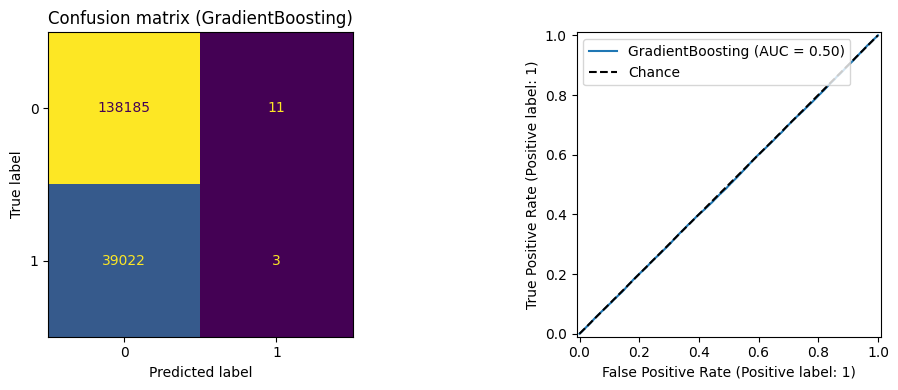

In [ ]:
print(classification_report(y_test, gb.predict(X_test), zero_division=0))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test, ax=ax[0], colorbar=False)
ax[0].set_title("Confusion matrix (GradientBoosting)")
RocCurveDisplay.from_estimator(gb, X_test, y_test, ax=ax[1], name="GradientBoosting")
ax[1].plot([0, 1], [0, 1], "k--", label="Chance"); ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the results:** accuracy alone is misleading here because ~78% of patients did not survive. A model that always says "not survived" already scores ~78%. Compare **recall, F1 and ROC-AUC** against the baseline. An AUC near 0.5 means the model is no better than guessing.

## 7. Feature importance

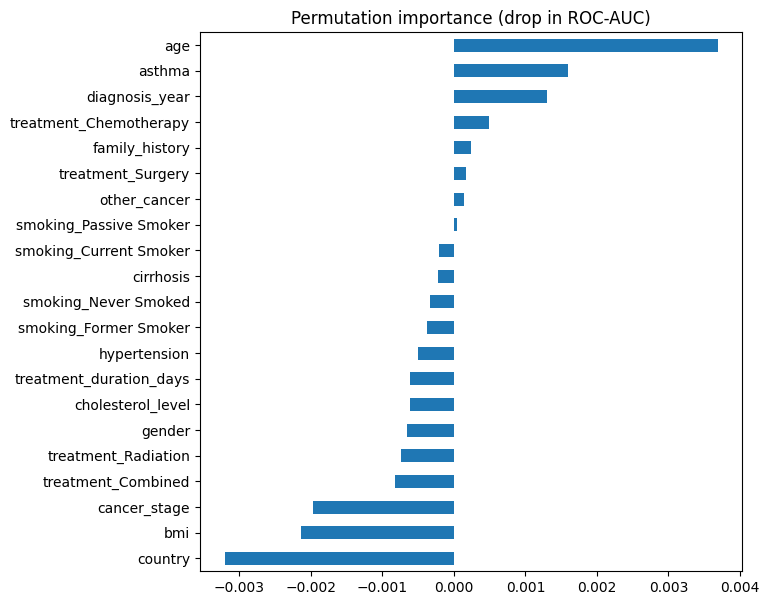

In [ ]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(gb, X_test.sample(20000, random_state=0),
                             y_test.loc[X_test.sample(20000, random_state=0).index],
                             scoring="roc_auc", n_repeats=3, random_state=42)
fi = pd.Series(imp.importances_mean, index=X.columns).sort_values()
fi.plot(kind="barh", figsize=(7,7), title="Permutation importance (drop in ROC-AUC)")
plt.show()

## 8. Hyperparameter tuning (optional)
Randomized search with 3-fold CV on a 30,000-row sample, scored by ROC-AUC (better than accuracy for imbalanced classes).

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
X_t, _, y_t, _ = train_test_split(X_train, y_train, train_size=30_000,
                                  random_state=1, stratify=y_train)
params = {"n_estimators": [100, 200, 300],
          "learning_rate": [0.03, 0.05, 0.1],
          "max_depth": [2, 3, 4, 5],
          "subsample": [0.6, 0.8, 1.0],
          "min_samples_leaf": [20, 50, 100]}
search = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), params,
                            n_iter=8, scoring="roc_auc", cv=3, n_jobs=-1,
                            random_state=42, verbose=1)
search.fit(X_t, y_t)
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", round(search.best_score_, 4))
best = search.best_estimator_
print("Test ROC-AUC (tuned):", round(roc_auc_score(y_test, best.predict_proba(X_test)[:,1]), 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 20, 'max_depth': 5, 'learning_rate': 0.05}
Best CV ROC-AUC: 0.4951
Test ROC-AUC (tuned): 0.4984
